# Manifold-VAEs

In [54]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [55]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
import lib.trainer as trainer
import lib.utils as utils
import lib.models.utils.save_load_models as modelutils



### Set up and initialize data loader

In [56]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [57]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)

### Model

In [72]:
data_dim = 784
latent_dim = 2
sftbeta = 1
device = "cpu"
encoder_width = 2
encoder_depth = 16
decoder_width = 1
decoder_depth = 16

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

#euclidean_model = models.EuclideanVAE(model_config)
toroidal_model = models.ToroidalVAE(model_config)

In [73]:
_, test_loader = dataloader
test_dataset = test_loader.dataset
image, _ = test_dataset[2]
x = image.unsqueeze(0).to(device)
posterior_params = toroidal_model.encode(x)
z = toroidal_model.reparameterize(posterior_params)
print("_______x1__________")
print("\n posterior", posterior_params, "\n z", z)
image, _ = test_dataset[3]
x = image.unsqueeze(0).to(device)
posterior_params = toroidal_model.encode(x)
z = toroidal_model.reparameterize(posterior_params)
print("_______x2__________")
print("\n posterior", posterior_params, "\n z", z)
#z_theta, z_phi = z
#print(torch.stack([z_theta, z_phi], dim=-1))

_______x1__________

 posterior tensor([[[ 0.9364,  1.1952,  1.9592],
         [ 0.2361, -1.0461,  2.2145]]], grad_fn=<StackBackward0>) 
 z tensor([[ 0.9902,  0.1394, -0.3433, -0.9392]])
_______x2__________

 posterior tensor([[[ 0.9364,  1.1952,  1.9592],
         [ 0.2361, -1.0461,  2.2145]]], grad_fn=<StackBackward0>) 
 z tensor([[ 0.4960,  0.8683,  0.3905, -0.9206]])


### Optimizer

In [74]:
learning_rate = 0.001

#euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)
toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [76]:
num_epochs = 2
log_interval = 100
device = "cpu"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device}

#euclidean_history = trainer.MVAETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()
toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the toroidalVAE model.
Starting epoch 1/2
Epoch [1/2], Step [100/938], Loss: 0.5222
Epoch [1/2], Step [200/938], Loss: 0.5269
Epoch [1/2], Step [300/938], Loss: 0.5068
Epoch [1/2], Step [400/938], Loss: 0.5177
Epoch [1/2], Step [500/938], Loss: 0.5152
Epoch [1/2], Step [600/938], Loss: 0.5043
Epoch [1/2], Step [700/938], Loss: 0.5108
Epoch [1/2], Step [800/938], Loss: 0.5077
Epoch [1/2], Step [900/938], Loss: 0.5083
Epoch 1/2, Train Loss: 0.0081, Test Loss: 0.0080
--------------------------------------------------
Starting epoch 2/2
Epoch [2/2], Step [100/938], Loss: 0.5082
Epoch [2/2], Step [200/938], Loss: 0.5149
Epoch [2/2], Step [300/938], Loss: 0.5061
Epoch [2/2], Step [400/938], Loss: 0.5052
Epoch [2/2], Step [500/938], Loss: 0.5106
Epoch [2/2], Step [600/938], Loss: 0.5099
Epoch [2/2], Step [700/938], Loss: 0.5002
Epoch [2/2], Step [800/938], Loss: 0.5132
Epoch [2/2], Step [900/938], Loss: 0.5056
Epoch 2/2, Train Loss: 0.0079, Test Loss

### Visualization 

In [ ]:
#utils.show_training_history(euclidean_history)

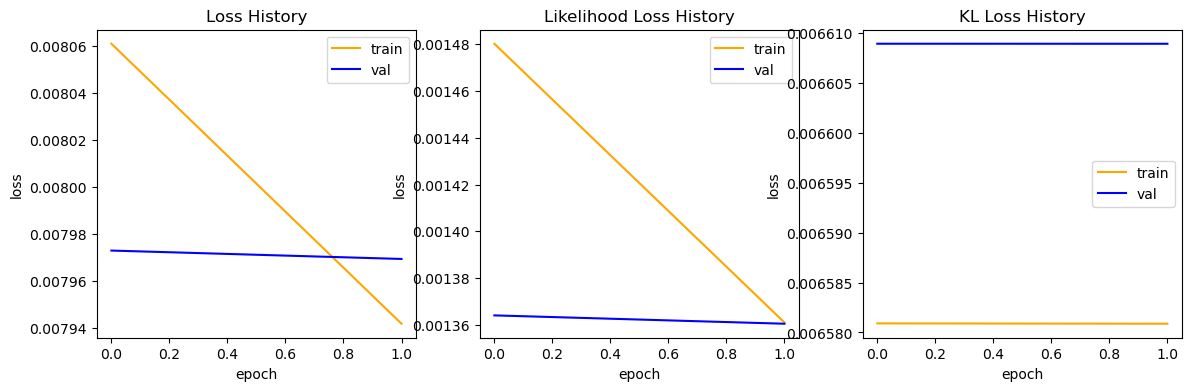

In [77]:
utils.show_training_history(toroidal_history)

### Save trained models

In [ ]:
#modelutils.save_model(euclidean_model, model_config)
modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [ ]:
#model = modelutils.load_model("gaussian_1738932113")

In [ ]:
#model

### Visualizing the latent space

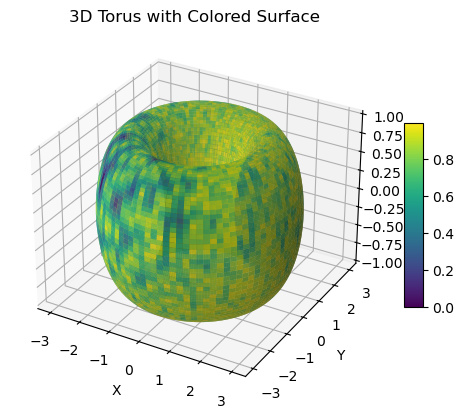

In [93]:
utils.plot_test_latents_on_torus(toroidal_model, test_loader, device)